# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

import pandas as pd

sys.path.append("..")

import importlib as imp

import warnings
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct

import cmasher as cmr
import plots

import experiment_settings
import mahalanobis
from build_data import build_data
import data_info

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "16 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
dpiFig = 300.0
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
EXP_NAME_VEC = (
    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
    "centered_bivariate_normal_104_EPCP60",
    "centered_bivariate_normal_105_EPCP72",
    "centered_bivariate_normal_106_EPCP84",
    "centered_bivariate_normal_107_EPCP96",
    "centered_bivariate_normal_108_EPCP108",
    "centered_bivariate_normal_109_EPCP120",
    )

RNG_SEED = 1
TESTING_YEAR = 2018
LONGITUDE_SCALING = 1.  #all longitudes are in degrees east in the dataset

In [5]:
# GET PREDICTIONS
df_pred_train = pd.DataFrame()
df_pred_valtest = pd.DataFrame()
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    try:
        (
            data_summary,
            x_train,
            onehot_train,
            x_val,
            onehot_val,
            x_test,
            onehot_test,
            x_valtest,
            onehot_valtest,
            df_train,
            df_val,
            df_test,
            df_valtest,
            ) = build_data(DATA_PATH, settings, verbose=0)
    except:
        continue

    # load the model
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"rng_seed_{settings['rng_seed']}"
    )
    try:
        model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
    except:
        continue

    # make dictionary of the predictions
    pred_dict_lead = {
        "exp_name": exp_name,
        "testing_year": TESTING_YEAR,
        }

    # copy dataframe and fill in the predictions
    df_train_lt = df_train.copy()
    df_valtest_lt = df_valtest.copy()
    df_test_lt = df_test.copy()

    df_train_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_train)
    df_valtest_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_valtest)
    # df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)
    try:
        df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)
    except:
        df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = np.nan

    df_train_lt["exp_name"] = exp_name
    df_valtest_lt["exp_name"] = exp_name
    df_test_lt["exp_name"] = exp_name

    # correct longitude for the Atlantic or Pacific
    df_train_lt["LONC"] = df_train_lt["LONC"] * LONGITUDE_SCALING
    df_valtest_lt["LONC"] = df_valtest_lt["LONC"] * LONGITUDE_SCALING
    df_test_lt["LONC"] = df_test_lt["LONC"] * LONGITUDE_SCALING

    # append to main dataframe
    df_pred_train = pd.concat([df_pred_train, df_train_lt], axis=0)
    df_pred_valtest = pd.concat([df_pred_valtest, df_valtest_lt], axis=0)
    df_pred_test = pd.concat([df_pred_test, df_test_lt], axis=0)

centered_bivariate_normal_100_EPCP12
centered_bivariate_normal_101_EPCP24
centered_bivariate_normal_102_EPCP36
centered_bivariate_normal_103_EPCP48
centered_bivariate_normal_104_EPCP60
centered_bivariate_normal_105_EPCP72
centered_bivariate_normal_106_EPCP84
centered_bivariate_normal_107_EPCP96
centered_bivariate_normal_108_EPCP108
centered_bivariate_normal_109_EPCP120


In [6]:
# error('here')

# Plot Results

In [7]:
plots.set_plot_rc()

In [8]:
df_pred_test

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OFDV,OBDV,DSDV,...,HWDY,LATC,PREDICTAND_X,PREDICTAND_Y,mu_u,mu_v,sigma_u,sigma_v,rho,exp_name
0,EP14,LANE,2018,82200,12,135.0,4,8.2,3.2,3.2,...,8.3,15.0,0.0,22.2,-0.0,0.0,24.598824,24.637522,-0.020941,centered_bivariate_normal_100_EPCP12
1,EP16,NORMAN,2018,83018,12,130.0,4,8.8,-1.2,4.8,...,-8.3,17.3,-10.7,11.1,-0.0,0.0,24.598824,24.637522,-0.020941,centered_bivariate_normal_100_EPCP12
2,EP17,OLIVIA,2018,90800,12,85.0,4,6.2,1.2,0.2,...,-13.9,21.3,0.0,-11.1,-0.0,0.0,24.598824,24.637522,-0.020941,centered_bivariate_normal_100_EPCP12
3,EP13,KRISTY,2018,80812,12,40.0,4,2.5,7.5,1.5,...,16.7,15.1,-21.5,11.1,-0.0,0.0,36.177017,35.202591,0.017518,centered_bivariate_normal_100_EPCP12
4,EP13,KRISTY,2018,80906,12,40.0,4,0.5,10.5,-1.5,...,-11.1,16.6,-10.6,0.0,-0.0,0.0,34.074345,33.294258,0.010448,centered_bivariate_normal_100_EPCP12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,EP16,NORMAN,2018,90118,120,90.0,4,-3.2,31.8,-1.2,...,333.3,22.0,103.6,133.3,-0.0,0.0,162.869766,131.918961,0.208651,centered_bivariate_normal_109_EPCP120
191,EP10,HECTOR,2018,80812,120,110.0,4,12.8,-27.2,14.8,...,155.5,24.1,0.0,-233.3,-0.0,0.0,155.318802,124.326996,0.204390,centered_bivariate_normal_109_EPCP120
192,EP10,HECTOR,2018,80300,120,95.0,4,17.0,37.0,8.0,...,52.8,16.8,53.3,11.1,-0.0,0.0,188.959961,157.577835,0.210422,centered_bivariate_normal_109_EPCP120
193,EP14,LANE,2018,81618,120,60.0,4,10.8,50.8,4.8,...,177.8,15.2,21.6,133.3,-0.0,0.0,220.865021,190.288544,0.215813,centered_bivariate_normal_109_EPCP120


60 dataframe is empty
84 dataframe is empty
108 dataframe is empty


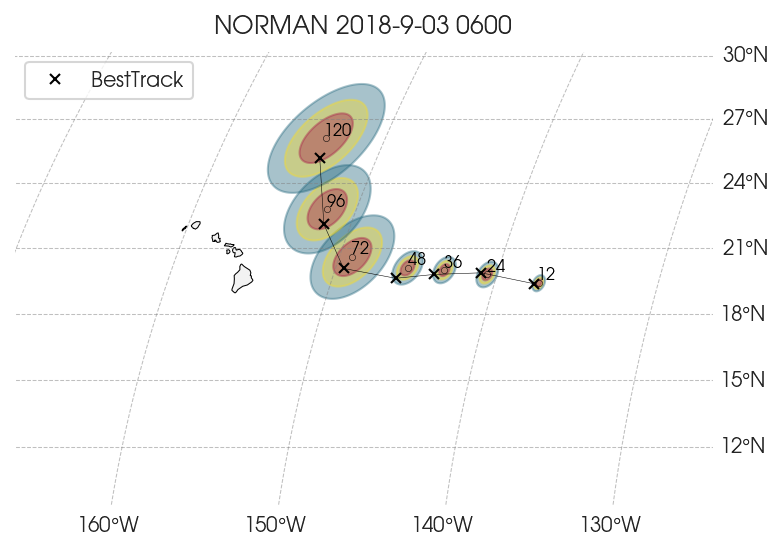

In [9]:
imp.reload(mahalanobis)
imp.reload(plots)

fig = plt.figure(dpi=150, )
ax = fig.add_subplot(1, 1, 1, projection=ct.crs.EqualEarth(central_longitude=0.))

# storm = {
#     "storm_name": "PALI",
#     "pred_time": 10812,
#     "extent": [195, 360-135, 5, 35],
#     }

storm = {
    "storm_name": "NORMAN",
    "pred_time": 90306,
    "extent": [195, 360-135, 5, 35],
    }
# storm = {"storm_name": "MICHAEL",
#          "pred_time": 100718,
#          "extent": [-100,-70,15,45],
#          }

df_storm = df_pred_test.loc[
    (df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])]
details = plots.plot_leadtime_predictions(
    df_storm,
    ax=ax,
    leadtimes=np.arange(12,120+12, 12),
    contours=(.25, .5, .75,),
    )
# ax.set_global()
ax.set_extent(storm["extent"], crs=ct.crs.PlateCarree())

# save the figure
plt.savefig(
    FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
    dpi=dpiFig,
    bbox_inches='tight',
    )
plt.show()

In [10]:
df_storm

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OFDV,OBDV,DSDV,...,HWDY,LATC,PREDICTAND_X,PREDICTAND_Y,mu_u,mu_v,sigma_u,sigma_v,rho,exp_name
252,EP16,NORMAN,2018,90306,12,110.0,4,-2.0,-7.0,2.0,...,8.3,19.4,31.4,11.1,-0.0,0.0,24.598824,24.637522,-0.020941,centered_bivariate_normal_100_EPCP12
414,EP16,NORMAN,2018,90306,24,110.0,4,-2.5,-12.5,1.5,...,30.6,19.8,62.7,11.1,-0.0,0.0,41.243050,39.225605,0.018742,centered_bivariate_normal_101_EPCP24
229,EP16,NORMAN,2018,90306,36,110.0,4,0.5,-9.5,-1.5,...,44.4,20.0,73.1,44.4,-0.0,0.0,43.458981,40.202415,0.001072,centered_bivariate_normal_102_EPCP36
74,EP16,NORMAN,2018,90306,48,110.0,4,1.0,6.0,-5.0,...,80.5,20.1,73.1,88.9,-0.0,0.0,57.038364,50.939041,0.064419,centered_bivariate_normal_103_EPCP48
263,EP16,NORMAN,2018,90306,72,110.0,4,2.8,37.8,-8.2,...,186.1,20.6,52.1,122.2,-0.0,0.0,151.620209,127.563568,0.174544,centered_bivariate_normal_105_EPCP72
174,EP16,NORMAN,2018,90306,96,110.0,4,-0.8,14.2,-10.8,...,333.3,22.8,10.1,155.6,-0.0,0.0,159.237701,135.964340,0.072443,centered_bivariate_normal_107_EPCP96
150,EP16,NORMAN,2018,90306,120,110.0,4,5.0,10.0,-7.0,...,383.3,26.1,-0.1,211.0,-0.0,0.0,200.865738,169.897141,0.212090,centered_bivariate_normal_109_EPCP120
